# 03 – Naive Baselines: Analyse & Vergleich

**Voraussetzung:** `03a_naive_persistence.ipynb` und `03b_naive_climatology.ipynb` wurden ausgeführt
und haben Ergebnisse nach `results/naive/` geschrieben.

Dieses Notebook:
1. Lädt alle Ergebnisse
2. Vergleicht Modelle (aggregiert + nach Saison)
3. Visualisiert Forecasts & Residuen
4. Bewertet, ob Metrikdifferenzen auf Saisonalität oder Modellqualität zurückgehen

## 0 · Setup

In [1]:
import sys
sys.path.insert(0, '..')

import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data.preprocessing import load_pv_data
from src.data.splitting import time_series_split, split_season_distribution
from src.models.naive import (
    persistence_forecast,
    fit_climatological_mean,
    predict_climatological_mean,
)

P_NOM  = 13500.0
TARGET = "Solarproduktion"
RESULTS_DIR = Path("../results/naive")

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

## 1 · Ergebnisse laden

In [2]:
results = {}
for path in sorted(RESULTS_DIR.glob("*.json")):
    with open(path) as f:
        r = json.load(f)
    results[r["model"]] = r

print(f"Geladene Modelle: {list(results.keys())}")

Geladene Modelle: ['climatology', 'persistence']


## 2 · Aggregierter Vergleich (Val & Test)

KEY_METRICS = ["rmse", "mae", "mbe", "r2", "skill_mae", "ramp_mae"]

def results_table(split: str) -> pd.DataFrame:
    return pd.DataFrame(
        {model: {k: r[split][k] for k in KEY_METRICS} for model, r in results.items()}
    ).T.round(3)

print("── Validierungsset ─────────────────────────────────────")
display(results_table("val"))
print("── Testset ─────────────────────────────────────────────")
display(results_table("test"))

## 3 · Saisonale Zusammensetzung der Splits

Val und Test decken unterschiedliche Jahreszeiten ab.  
Das erklärt einen Teil der Metrikdifferenz zwischen Val und Test – **nicht Overfitting**.

In [3]:
df = load_pv_data()
train, val, test = time_series_split(df, val_frac=0.15, test_frac=0.15)

print("Saisonale Verteilung pro Split (Anteil):")
split_season_distribution(train, val, test)

Saisonale Verteilung pro Split (Anteil):


timestamp,Winter,Spring,Summer,Autumn
train,0.235,0.321,0.231,0.212
val,0.084,0.000,0.421,0.494
test,0.410,0.500,0.090,0.000


## 4 · Metriken nach Saison

Höheres RMSE im Sommer = mehr PV-Produktion und Varianz, **nicht** schlechteres Modell.

In [4]:
for split in ["val", "test"]:
    print(f"\n{'═'*55}")
    print(f"  {split.upper()} – RMSE nach Saison")
    print(f"{'═'*55}")
    rows = {}
    for model, r in results.items():
        by_season = r[f"{split}_by_season"]
        rows[model] = {s: v["rmse"] for s, v in by_season.items()}
    display(pd.DataFrame(rows).T.round(0))


═══════════════════════════════════════════════════════
  VAL – RMSE nach Saison
═══════════════════════════════════════════════════════


,Winter,Summer,Autumn
climatology,392.0,407.0,302.0
persistence,225.0,392.0,289.0



═══════════════════════════════════════════════════════
  TEST – RMSE nach Saison
═══════════════════════════════════════════════════════


,Winter,Spring,Summer
climatology,353.0,350.0,397.0
persistence,276.0,373.0,411.0


## 5 · Visualisierung: Beispielwoche

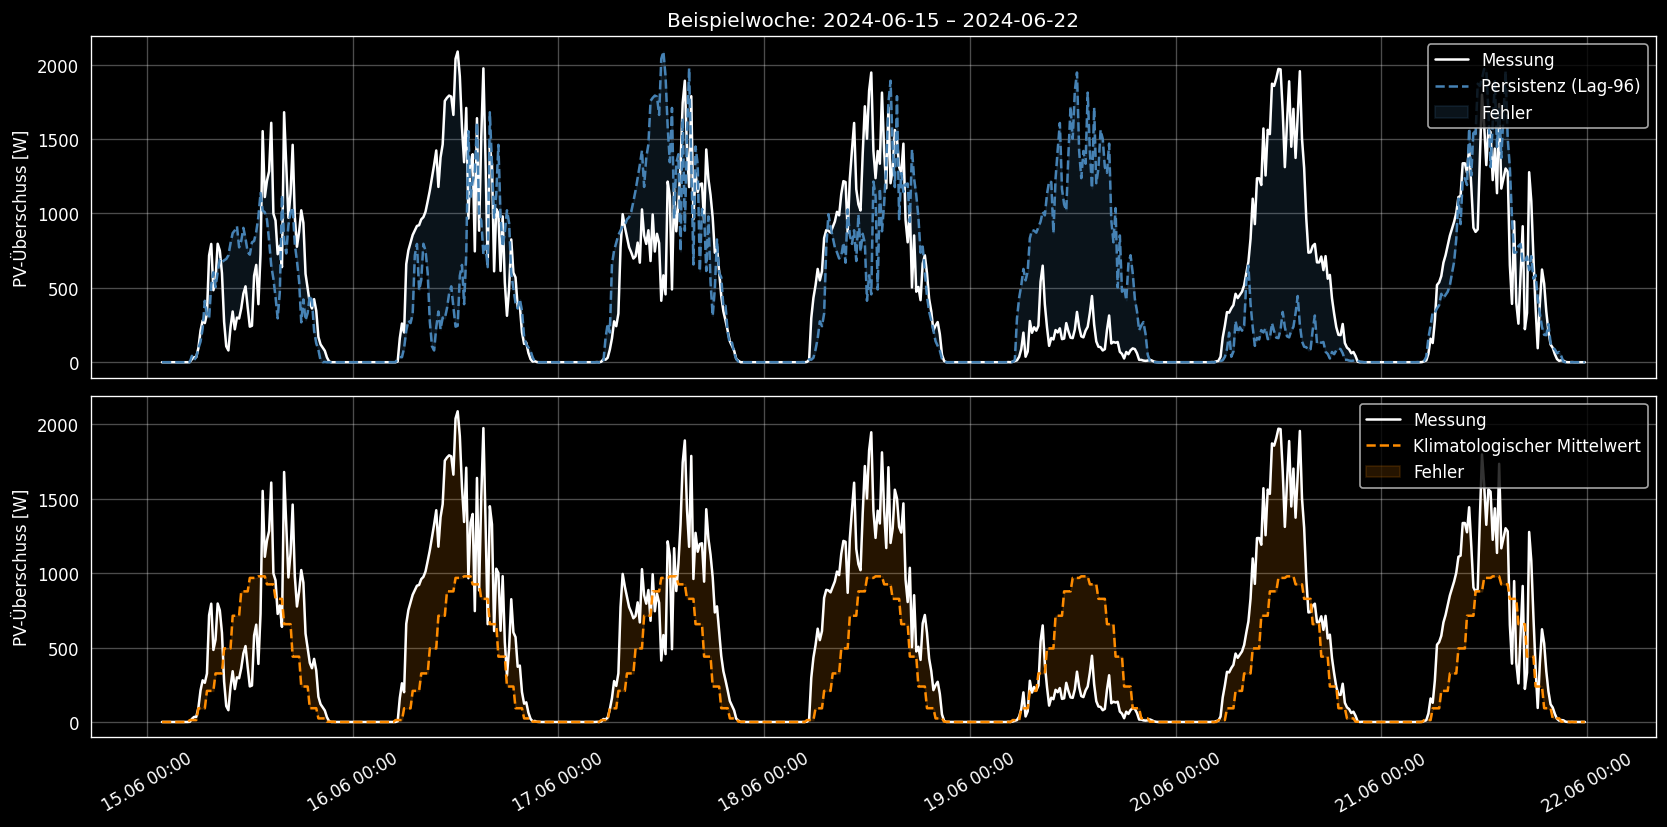

In [5]:
# Prognosen neu berechnen für Plots
full_pers = persistence_forecast(df.set_index("timestamp")[TARGET], lag=96)
hourly_means = fit_climatological_mean(train, TARGET)

y_val  = val.set_index("timestamp")[TARGET]
pred_pers_val = full_pers.reindex(y_val.index)
pred_clim_val = predict_climatological_mean(hourly_means, val).set_axis(y_val.index)

week_start = val["timestamp"].min().normalize()
week_end   = week_start + pd.Timedelta(days=7)
mask       = (y_val.index >= week_start) & (y_val.index < week_end)

ts   = y_val.index[mask]
y_w  = y_val[mask]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, pred, label, color in [
    (axes[0], pred_pers_val[mask], "Persistenz (Lag-96)",       "steelblue"),
    (axes[1], pred_clim_val[mask], "Klimatologischer Mittelwert", "darkorange"),
]:
    ax.plot(ts, y_w,   label="Messung", color="white",  lw=1.5)
    ax.plot(ts, pred,  label=label,     color=color,    lw=1.5, linestyle="--")
    ax.fill_between(ts, y_w, pred, alpha=0.15, color=color, label="Fehler")
    ax.set_ylabel("PV-Überschuss [W]")
    ax.legend(loc="upper right")

axes[0].set_title(f"Beispielwoche: {week_start.date()} – {week_end.date()}")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d.%m %H:%M"))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6 · Residuenverteilung

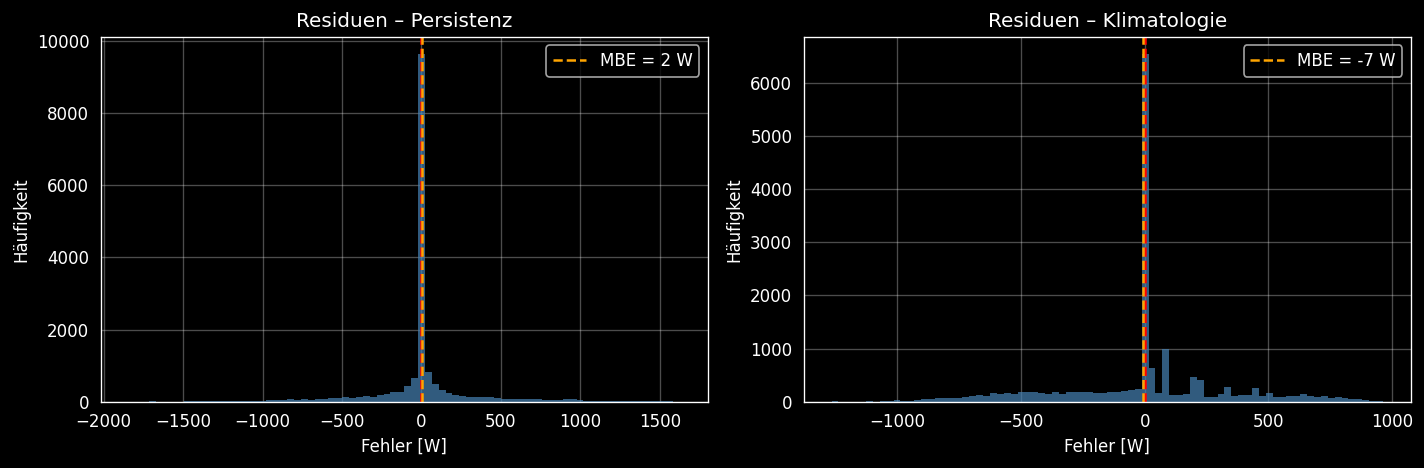

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred, label in [
    (axes[0], pred_pers_val, "Persistenz"),
    (axes[1], pred_clim_val, "Klimatologie"),
]:
    residuals = (pred - y_val).dropna()
    ax.hist(residuals, bins=80, color="steelblue", alpha=0.7, edgecolor="none")
    ax.axvline(0,               color="red",    lw=1.5, linestyle="--")
    ax.axvline(residuals.mean(), color="orange", lw=1.5, linestyle="--",
               label=f"MBE = {residuals.mean():.0f} W")
    ax.set(title=f"Residuen – {label}", xlabel="Fehler [W]", ylabel="Häufigkeit")
    ax.legend()

plt.tight_layout()
plt.show()

## 7 · Zusammenfassung

- **Persistenz-RMSE / MAE auf dem Testset** → das ist die Hürde für spätere ML-Modelle
- **Skill Score > 0** → besser als Persistenz
- **Val vs. Test Metrikdifferenz** → zum Teil saisonal bedingt (Val: sommer-lastig, Test: winter-lastig)
  → saisonale Breakdowns (Abschnitt 4) für faire Interpretation nutzen

Nächste Schritte:
- Feature Engineering (Notebook 02)
- Lineare Regression als nächste Baseline (Notebook 04)
- Gradient Boosting / Random Forest (Notebook 05)